### Import Necessary Packages and Libraries

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import joblib

In [3]:
# Read in csv
df = pd.read_csv('~/Desktop/ADA/ADA-final-project/data_ingestion/preprocessed_award_data.csv')

# Predict Modification within 1 Year (Binary)

In [12]:
# Define columns for Machine Learning Processing
categorical_predictors = ['Awarding Agency' , 'Awarding Sub Agency', 'Funding Agency',
                         'Funding Sub Agency', 'Place of Performance Country Code', 'Place of Performance State Code',
                         'is_democrat', 'naics_code', 'start_year'] # leave out psc_code (~ 900 values)
continuous_predictors = ['Award Amount', 'market_share']
target = 'is_within_year'
metadata = ['internal_id', 'Award ID_x', 'generated_internal_id', 'Recipient Name', 'recipient_id']

In [16]:
df = df[categorical_predictors + continuous_predictors + [target]]
df = df.dropna() # Only drops a few thousand records - insignificant comparatively

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 241966 entries, 2 to 247240
Data columns (total 12 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Awarding Agency                    241966 non-null  object 
 1   Awarding Sub Agency                241966 non-null  object 
 2   Funding Agency                     241966 non-null  object 
 3   Funding Sub Agency                 241966 non-null  object 
 4   Place of Performance Country Code  241966 non-null  object 
 5   Place of Performance State Code    241966 non-null  object 
 6   is_democrat                        241966 non-null  int64  
 7   naics_code                         241966 non-null  float64
 8   start_year                         241966 non-null  float64
 9   Award Amount                       241966 non-null  float64
 10  market_share                       241966 non-null  float64
 11  is_within_year                     241966 no

## Baseline Logistic Regression
### Run K Fold Cross Validation Grid Search

In [31]:
# We use handle_unknown='ignore' for OneHot so the model doesn't crash 
# if the test set has a brand new Agency or NAICS code.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_predictors),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_predictors)
    ])

# Create the Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
    ))
])

# Split Data
X = df[categorical_predictors + continuous_predictors]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Hyperparameters for Grid Search
# 'C' is inverse regularization strength (smaller = more regularization)
# 'penalty' defines L1 (Lasso) vs L2 (Ridge)
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
}

In [32]:
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=3 
    )

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Evaluation
y_pred_lr = grid_search.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lr))

Starting Grid Search...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 1/5] END .....................classifier__C=1;, score=nan total time=   0.1s
[CV 1/5] END ...................classifier__C=0.1;, score=nan total time=   0.1s
[CV 2/5] END .....................classifier__C=1;, score=nan total time=   0.1s
[CV 4/5] END ....................classifier__C=10;, score=nan total time=   0.1s
[CV 5/5] END ...................classifier__C=100;, score=nan total time=   0.1s
[CV 2/5] END ................classifier__C=0.01;, score=0.431 total time=   0.3s


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 5/5] END ...................classifier__C=0.1;, score=nan total time=   0.1s
[CV 4/5] END ....................classifier__C=10;, score=nan total time=   0.1s
[CV 1/5] END ..................classifier__C=0.01;, score=nan total time=   0.1s
[CV 2/5] END ...................classifier__C=0.1;, score=nan total time=   0.1s
[CV 3/5] END .....................classifier__C=1;, score=nan total time=   0.1s
[CV 5/5] END ....................classifier__C=10;, score=nan total time=   0.1s
[CV 4/5] END ................classifier__C=0.01;, score=0.443 total time=   0.3s
[CV 1/5] END ...................classifier__C=0.1;, score=nan total time=   0.1s
[CV 1/5] END ....................classifier__C=10;, score=nan total time=   0.1s
[CV 2/5] END ...................classifier__C=100;, score=nan total time=   0.1s
[CV 4/5] END ...................classifier__C=0.1;, score=nan total time=   0.1s
[CV 3/5] END ....................classifier__C=10;, score=nan total time=   0.1s
[CV 4/5] END ...............

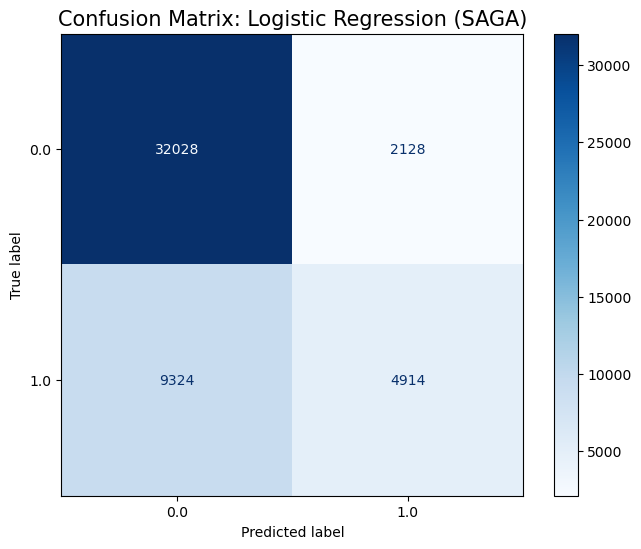

In [33]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: Logistic Regression (SAGA)', fontsize=15)
plt.grid(False) # Clean up background lines
plt.show()

## Decision Tree

In [35]:
# Define the Decision Tree Pipeline
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Hyperparameters: focus on depth and leaf constraints to prevent overfitting
dt_param_grid = {
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 10, 20],
    'classifier__criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(dt_pipeline, dt_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose = 3)
dt_grid.fit(X_train, y_train)

print(f"Decision Tree Best Params: {dt_grid.best_params_}")

# Evaluation
y_pred_dt = dt_grid.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_dt))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 2/5] END ..................classifier__C=0.01;, score=nan total time=   0.1s
[CV 4/5] END ...................classifier__C=100;, score=nan total time=   0.1s
[CV 4/5] END .....................classifier__C=1;, score=nan total time=   0.1s
[CV 1/5] END ...................classifier__C=100;, score=nan total time=   0.1s
[CV 2/5] END ...................classifier__C=1;, score=0.454 total time=   0.6s
[CV 4/5] END .................classifier__C=100;, score=0.461 total time=   0.6s
[CV 3/5] END classifier__criterion=gini, classifier__max_depth=None, classifier__min_samples_split=10;, score=0.534 total time=   7.6s


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 3/5] END ..................classifier__C=0.01;, score=nan total time=   0.1s
[CV 5/5] END .....................classifier__C=1;, score=nan total time=   0.1s
[CV 5/5] END ...................classifier__C=100;, score=nan total time=   0.1s
[CV 2/5] END ..................classifier__C=0.01;, score=nan total time=   0.1s
[CV 3/5] END ...................classifier__C=0.1;, score=nan total time=   0.1s
[CV 5/5] END .....................classifier__C=1;, score=nan total time=   0.1s
[CV 4/5] END .................classifier__C=0.1;, score=0.456 total time=   0.4s
[CV 5/5] END ..................classifier__C=10;, score=0.462 total time=   0.6s
[CV 2/5] END classifier__criterion=gini, classifier__max_depth=None, classifier__min_samples_split=20;, score=0.533 total time=   7.5s
[CV 2/5] END .....................classifier__C=1;, score=nan total time=   0.1s
[CV 1/5] END ...................classifier__C=100;, score=nan total time=   0.1s
[CV 5/5] END .................classifier__C=0.1;, score

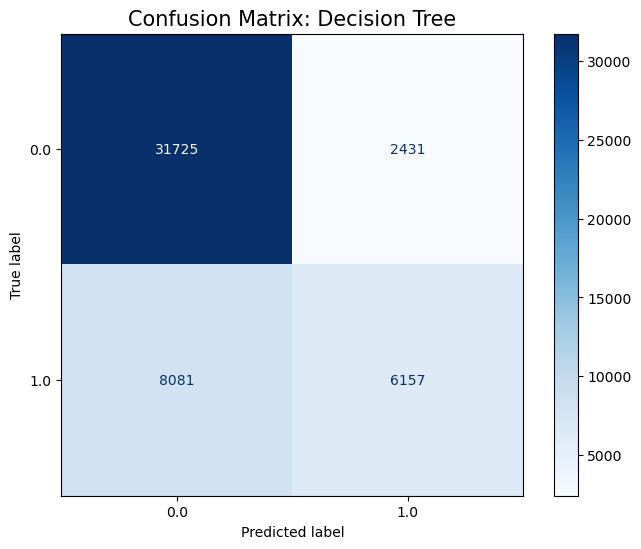

In [36]:
# Generate the confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=grid_search.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: Decision Tree', fontsize=15)
plt.grid(False) # Clean up background lines
plt.show()

## Random Forest

In [41]:
# Define the Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Hyperparameters: 'n_estimators' is the number of trees
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Random Forest Best Params: {rf_grid.best_params_}")

# Evaluation
y_pred_rf = rf_grid.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf))


--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.81      0.87      0.84     34156
         1.0       0.61      0.51      0.56     14238

    accuracy                           0.76     48394
   macro avg       0.71      0.69      0.70     48394
weighted avg       0.75      0.76      0.76     48394



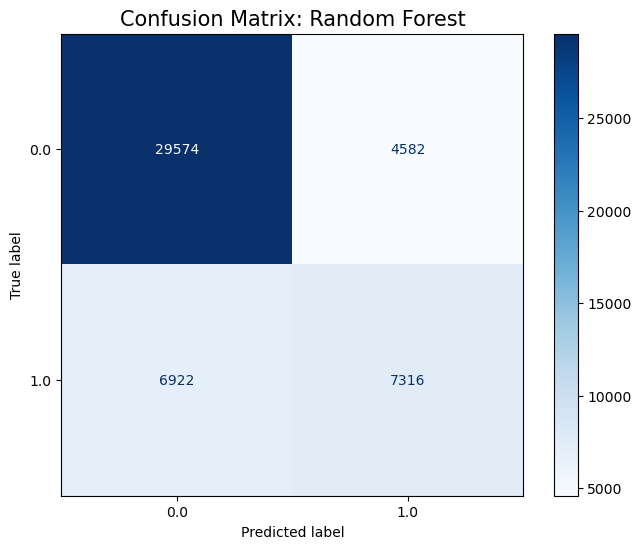

In [54]:
# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=grid_search.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: Random Forest', fontsize=15)
plt.grid(False) # Clean up background lines
plt.show()

## XGBoost

In [42]:
# Define the XGBoost Pipeline
# XGBoost handles its own weights, but likes the same preprocessed data
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# Hyperparameters: 'learning_rate' (eta) and 'n_estimators' are key
xgb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 6, 9]
}

xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print(f"XGBoost Best Params: {xgb_grid.best_params_}")

# Evaluation
y_pred_xgb = xgb_grid.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_xgb))


--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.81      0.92      0.86     34156
         1.0       0.73      0.49      0.58     14238

    accuracy                           0.80     48394
   macro avg       0.77      0.71      0.72     48394
weighted avg       0.79      0.80      0.78     48394



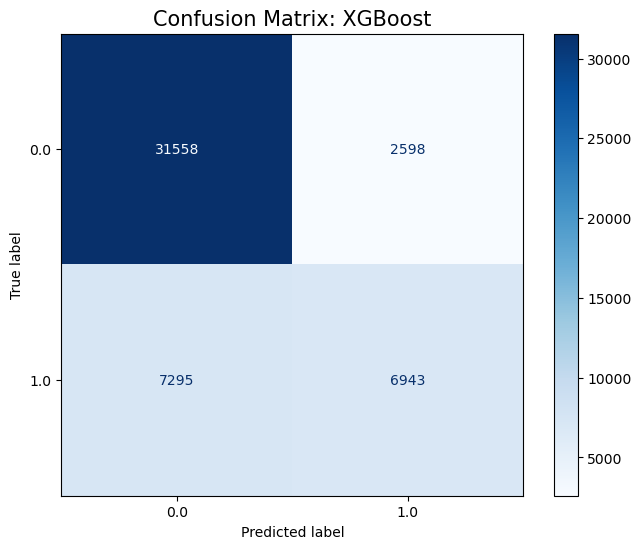

In [52]:
# Generate the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=grid_search.classes_)

disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix: XGBoost', fontsize=15)
plt.grid(False) # Clean up background lines
plt.show()

# Save Models and Metrics to Disk

In [45]:
version = "v1"

# IMPORTANT!!!!
## Ensure Proper Version Number above is specified before running!

In [60]:
# Dictionary to map your trained grid objects to filenames
model_dict = {
    "Logistic Regression": grid_search,
    "Decision Tree": dt_grid,
    "Random Forest": rf_grid,
    "XGBoost": xgb_grid
}

results_list = []

for name, grid in model_dict.items():
    # Save the model
    filename = f"models/{name.lower().replace(' ', '_')}_model_{version}.joblib"
    joblib.dump(grid.best_estimator_, filename)
    
    # Get predictions for evaluation
    y_pred = grid.predict(X_test)
    
    # Calculate metrics
    # We use classification_report output_dict=True to get all metrics easily
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results_list.append({
        "model_name": name + "_" + version,
        "model_location": filename,
        "precision": report['1.0']['precision'],
        "recall": report['1.0']['recall'],
        "f1_score": report['1.0']['f1-score'],
        "weighted_avg_f1": report['weighted avg']['f1-score'],
        "macro_avg_f1": report['macro avg']['f1-score']
    })

# Create the summary CSV
df_metrics_old = pd.read_csv("modification_model_evaluation_metrics.csv")

df_metrics = pd.concat([df_metrics_old, pd.DataFrame(results_list)], axis = 0)
df_metrics = df_metrics.drop_duplicates()

df_metrics.to_csv("modification_model_evaluation_metrics.csv", index=False)

print("Models saved and metrics CSV generated successfully.")

Models saved and metrics CSV generated successfully.
